In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dataset Iris: 150 bunga, 4 fitur, 3 kelas (setosa, versicolor, virginica).
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

# Logistic Regression: model statistik yang menghitung probabilitas tiap kelas.
lr = LogisticRegression(max_iter=200).fit(X_train, y_train)

# Decision Tree: model pohon keputusan yang memecah data berdasarkan aturan if-else.
dt = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

# Loop untuk mengevaluasi kedua model sekaligus.
for name, model in {"LogReg": lr, "DecisionTree": dt}.items():
    pred = model.predict(X_test)
    print(f"\n{name} accuracy:", round(accuracy_score(y_test, pred), 3))
    print(confusion_matrix(y_test, pred))           # tabel prediksi vs aktual
    print(classification_report(y_test, pred, target_names=iris.target_names))  # precision, recall, F1


LogReg accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


DecisionTree accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



##Klasifikasi Dataset Iris Menggunakan Logistic Regression dan Decision Tree
# Tujuan
Tujuan dari praktikum ini adalah untuk mempelajari metode klasifikasi dalam machine learning menggunakan Python. Pada praktikum ini digunakan dua algoritma yaitu Logistic Regression dan Decision Tree Classifier untuk mengklasifikasikan data pada dataset Iris. Selain itu praktikum ini juga bertujuan untuk memahami cara melakukan evaluasi model menggunakan confusion matrix, classification report, dan accuracy score.

#Langkah Kerja
1. Mengimpor library yang dibutuhkan dalam program.
2. Memuat dataset Iris dari Scikit-Learn.
3. Membagi data menjadi data training dan data testing.
4. Membuat model Logistic Regression.
5. Membuat model Decision Tree Classifier.
6. Melakukan prediksi menggunakan kedua model.
7. Mengevaluasi model menggunakan classification report dan confusion matrix.
8. Menampilkan visualisasi confusion matrix.
9. Menampilkan struktur pohon keputusan dari Decision Tree.
10. Membandingkan akurasi kedua model dan membuat kesimpulan.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Pada bagian ini saya mengimpor beberapa library yang diperlukan dalam program. Library pandas digunakan untuk mengolah data, seaborn dan matplotlib digunakan untuk membuat visualisasi grafik. Selain itu digunakan juga beberapa modul dari Scikit-Learn untuk memuat dataset, membagi data menjadi training dan testing, membuat model klasifikasi, serta melakukan evaluasi model.

In [2]:
# 1. PERSIAPAN DATA (Iris Dataset)

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

Pada bagian ini dataset Iris dimuat menggunakan fungsi load_iris(). Dataset ini berisi informasi mengenai ukuran bunga iris seperti sepal length, sepal width, petal length, dan petal width. Data kemudian dibagi menjadi data training dan data testing dengan perbandingan 80% untuk training dan 20% untuk testing menggunakan fungsi train_test_split.

Output pada bagian ini tidak menampilkan hasil secara langsung, tetapi menghasilkan variabel X_train, X_test, y_train, dan y_test yang akan digunakan untuk melatih dan menguji model klasifikasi.

In [4]:
# 2. TRAINING MODEL
# Logistic Regression (Metode Statistik)
lr = LogisticRegression(max_iter=200).fit(X_train, y_train)

# Decision Tree (Metode Logika If-Else)
dt = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

Pada bagian ini saya membuat dua model klasifikasi yaitu Logistic Regression dan Decision Tree Classifier. Model Logistic Regression digunakan untuk melakukan klasifikasi berdasarkan pendekatan statistik. Sedangkan Decision Tree menggunakan pendekatan logika if-else untuk menentukan kelas dari data. Kedua model kemudian dilatih menggunakan data training.

Pada bagian ini juga tidak muncul output yang terlihat dikarenakan proses yang dilakukan adalah training model. Model yang sudah dilatih akan digunakan pada tahap evaluasi.


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



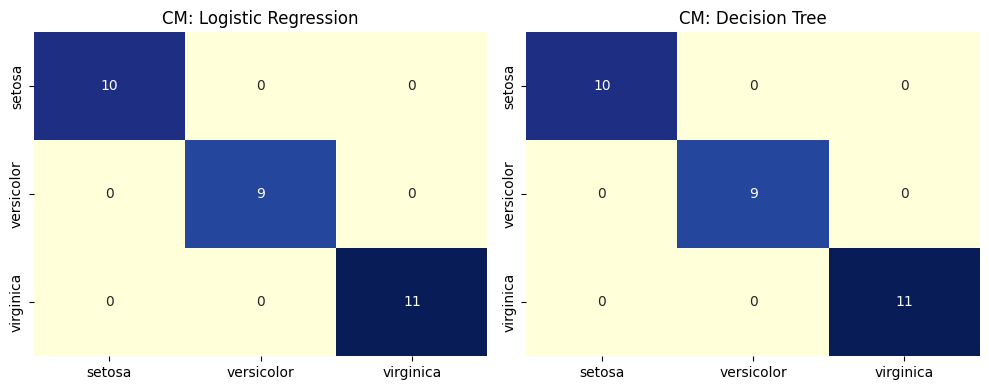

In [5]:
# 3. EVALUASI & CONFUSION MATRIX (UKURAN KECIL)

models = {"Logistic Regression": lr, "Decision Tree": dt}
fig, axes = plt.subplots(1, 2, figsize=(10, 4)) # Ukuran kecil & berdampingan

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)

    # Print laporan metrik di terminal
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))

    # Heatmap Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[i], cbar=False,
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    axes[i].set_title(f"CM: {name}")

plt.tight_layout()
plt.show()

Pada bagian ini dilakukan evaluasi terhadap kedua model klasifikasi. Program melakukan prediksi menggunakan data testing kemudian menghitung classification report yang berisi nilai precision, recall, dan f1-score. Selain itu juga dibuat confusion matrix untuk melihat jumlah prediksi yang benar dan salah pada setiap kelas.

Output yang dihasilkan berupa classification report yang menunjukkan performa model pada setiap kelas bunga iris. Selain itu juga ditampilkan confusion matrix dalam bentuk heatmap yang memperlihatkan jumlah prediksi yang benar dan salah pada masing-masing kelas.

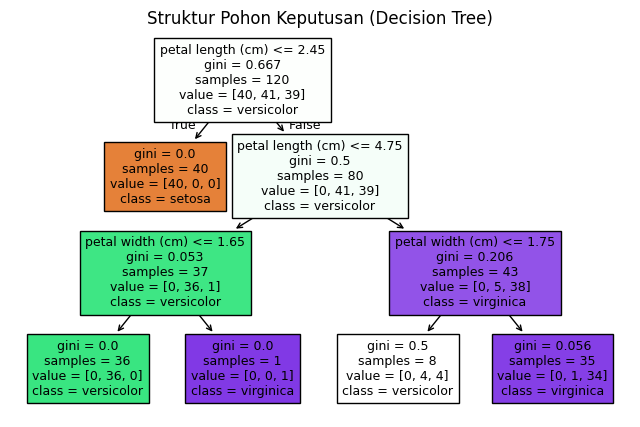

In [6]:
# 4. VISUALISASI POHON KEPUTUSAN (UKURAN KECIL)

plt.figure(figsize=(8, 5))
plot_tree(dt, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, fontsize=9)
plt.title("Struktur Pohon Keputusan (Decision Tree)")
plt.show()

Pada bagian ini ditampilkan visualisasi struktur pohon keputusan dari model Decision Tree. Diagram pohon ini menunjukkan bagaimana model mengambil keputusan berdasarkan nilai fitur yang ada.

Output yang dihasilkan berupa diagram pohon keputusan yang memperlihatkan proses klasifikasi data berdasarkan nilai fitur tertentu. Struktur pohon ini membantu memahami bagaimana model membuat keputusan.

In [7]:
# 5. KESIMPULAN

lr_acc = accuracy_score(y_test, lr.predict(X_test))
dt_acc = accuracy_score(y_test, dt.predict(X_test))

print("\n=== KESIMPULAN AKHIR ===")
print(f"Akurasi Logistic Regression: {lr_acc:.3f}")
print(f"Akurasi Decision Tree: {dt_acc:.3f}")
print("\nAnalisis: Kedua model bekerja sangat baik pada dataset Iris.")
print("Logistic Regression unggul dalam memproses hubungan linear antar fitur,")
print("sedangkan Decision Tree sangat bagus karena logikanya mudah diikuti (seperti sistem pakar).")


=== KESIMPULAN AKHIR ===
Akurasi Logistic Regression: 1.000
Akurasi Decision Tree: 1.000

Analisis: Kedua model bekerja sangat baik pada dataset Iris.
Logistic Regression unggul dalam memproses hubungan linear antar fitur,
sedangkan Decision Tree sangat bagus karena logikanya mudah diikuti (seperti sistem pakar).


Pada bagian ini saya menghitung nilai akurasi dari dua model yaitu Logistic Regression dan Decision Tree menggunakan fungsi accuracy_score(). Nilai akurasi digunakan untuk melihat seberapa baik model dalam mengklasifikasikan data uji.
Setelah itu program menampilkan hasil akurasi dari masing-masing model serta analisis singkat mengenai kinerja kedua model pada dataset Iris.


